# Explainability of ML Models with SHAP

In the previous sessions, we learned how to train machine learning models and evaluate their performance. But especially in the medical domain, it is often not enough to have a model that performs well, we also need to **understand why** a model makes a certain prediction.

This is especially important for:
* **Clinical trust**: Physicians need to understand a model's reasoning before relying on it for patient care
* **Regulatory compliance**: Medical AI systems often need to provide explanations for their decisions
* **Debugging**: Understanding which features drive predictions helps to identify potential biases or errors
* **Scientific insight**: Feature importance can reveal clinically relevant patterns in the data

In this notebook, we will use **SHAP (SHapley Additive exPlanations)** to explain predictions from two different model types:
* A **RandomForest** classifier (tree-based model)
* A **Multi-Layer Perceptron (MLP)** classifier (neural network)

We will use the following modules for this:
* [sklearn.datasets](https://scikit-learn.org/stable/api/sklearn.datasets.html): Tools for using common datasets for ML
* [sklearn.model_selection](https://scikit-learn.org/stable/api/sklearn.model_selection.html): Tools for data splitting and parameter tuning
* [sklearn.ensemble](https://scikit-learn.org/stable/api/sklearn.ensemble.html): Collection of ensemble-based models
* [sklearn.neural_network](https://scikit-learn.org/stable/api/sklearn.neural_network.html): Neural network models including MLP
* [sklearn.preprocessing](https://scikit-learn.org/stable/api/sklearn.preprocessing.html): Tools for feature scaling
* [sklearn.metrics](https://scikit-learn.org/stable/api/sklearn.metrics.html): Collection of various metrics for model evaluation
* [shap](https://shap.readthedocs.io/en/latest/): SHAP values for model interpretability

**In general, also refer to the comprehensive [SHAP documentation](https://shap.readthedocs.io/en/latest/) for further details.**

In [1]:
# Just in case we need help
# Import bia-bob as a helpful Python & Medical AI expert
import os
from bia_bob import bob

bob.initialize(
    endpoint=os.getenv('ENDPOINT_URL'),
    model="vllm-llama-4-scout-17b-16e-instruct",
    system_prompt=os.getenv('SYSTEM_PROMPT_MEDICAL_AI')
)

In [2]:
%bob Who are you ? Just 1 sentence!

I'm an expert in medical data science and a skilled Python programmer and data analyst with extensive experience working with various medical datasets and applying data analysis, machine learning, and deep learning techniques.

## Background: What is SHAP?

SHAP is based on **Shapley values** from cooperative game theory. The key idea: imagine each feature as a "player" in a team. The Shapley value fairly distributes the total "payout" (the model's prediction) among all players (features) based on their individual contributions.

For each prediction, SHAP tells us:
* **Which features** pushed the prediction higher or lower
* **By how much** each feature contributed

This works for **any** machine learning model, which is a major advantage over model-specific methods like tree-based feature importances.

## Data Preparation

We will use the [scikit-learn diabetes dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) for a **classification** task. The original dataset contains a continuous target variable (disease progression measure). We will convert this into a binary classification problem: predicting whether a patient has **high** or **low** disease progression.

Let's load and prepare the data:

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

In [4]:
# Let's get our features X and target y
X = diabetes.data
y_continuous = diabetes.target
feature_labels = diabetes.feature_names

print("Shape X:", X.shape)
print("Feature names:", feature_labels)
print("Target (continuous) - first 10 values:", y_continuous[:10])
print(f"Target range: {y_continuous.min()} to {y_continuous.max()}")

# Convert to binary classification:
# "high" disease progression (1) if above the median, "low" (0) otherwise
median_target = np.median(y_continuous)
y = (y_continuous >= median_target).astype(int)

print(f"\nMedian target threshold: {median_target}")
print(f"Class distribution: low (0) = {np.sum(y == 0)}, high (1) = {np.sum(y == 1)}")

Shape X: (442, 10)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target (continuous) - first 10 values: [151.  75. 141. 206. 135.  97. 138.  63. 110. 310.]
Target range: 25.0 to 346.0

Median target threshold: 140.5
Class distribution: low (0) = 221, high (1) = 221


Let's also create a DataFrame for easier inspection of the data:

In [5]:
df = pd.DataFrame(X, columns=feature_labels)
df['target'] = y
df.head(5)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,1
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,1
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,1
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,0


### Train-test split

As before, we split the data into training and test sets to evaluate the generalization of our models on unseen data.

In [6]:
from sklearn.model_selection import train_test_split

# Split: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training data:", X_train.shape, "Training labels:", y_train.shape)
print("Test data:", X_test.shape, "Test labels:", y_test.shape)
print(f"\nClass distribution in training set: low = {np.sum(y_train == 0)}, high = {np.sum(y_train == 1)}")
print(f"Class distribution in test set: low = {np.sum(y_test == 0)}, high = {np.sum(y_test == 1)}")

Training data: (353, 10) Training labels: (353,)
Test data: (89, 10) Test labels: (89,)

Class distribution in training set: low = 176, high = 177
Class distribution in test set: low = 45, high = 44


## Part 1: RandomForest Classifier

### Training the model

Let's train a [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) with hyperparameter tuning using [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

# Set up GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='accuracy',
    cv=5
)

# Train with grid search
grid_search_rf.fit(X_train, y_train)

print("Best parameters:", grid_search_rf.best_params_)
print(f"Best cross-validation accuracy: {grid_search_rf.best_score_:.3f}")

best_rf = grid_search_rf.best_estimator_

Best parameters: {'max_depth': 5, 'n_estimators': 50}
Best cross-validation accuracy: 0.742


### Evaluation

RandomForest - Classification Report:
              precision    recall  f1-score   support

         low       0.80      0.62      0.70        45
        high       0.69      0.84      0.76        44

    accuracy                           0.73        89
   macro avg       0.74      0.73      0.73        89
weighted avg       0.74      0.73      0.73        89



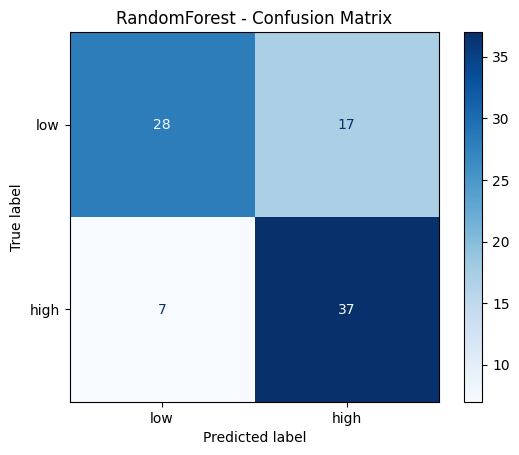

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predict on test data
y_pred_rf = best_rf.predict(X_test)

# Print evaluation metrics
print("RandomForest - Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['low', 'high']))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['low', 'high'])
disp.plot(cmap='Blues')
plt.title('RandomForest - Confusion Matrix')
plt.show()

### Explainability with SHAP

Now comes the core of this session: using SHAP to understand **why** the RandomForest makes its predictions.

For tree-based models, SHAP provides a highly efficient [`TreeExplainer`](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html) that computes exact SHAP values.

In [9]:
import shap

# Create a TreeExplainer for our RandomForest model
explainer_rf = shap.TreeExplainer(best_rf, feature_names=feature_labels)

# Compute SHAP values for the test data
shap_values_rf = explainer_rf.shap_values(X_test)

# Also compute as Explanation object — required for waterfall plots
shap_exp_rf = explainer_rf(X_test)

#### Understanding the SHAP output

For a binary classifier, `shap_values` returns a **3D numpy array** of shape `(n_samples, n_features, n_classes)`.  
The third dimension indexes the two classes (0 = "low", 1 = "high").  
Each entry tells us how much that feature contributed to the predicted probability of the corresponding class for that specific sample.

Let's look at the shape:

In [10]:
# shap_values_rf is a 3D array with shape (n_samples, n_features, n_classes)
print("Shape of SHAP values array:", shap_values_rf.shape)
print(f"This means: for each of the {X_test.shape[0]} test samples, we have {X_test.shape[1]} SHAP values per class")
print("\nTo get SHAP values for class 'high' (1): shap_values_rf[:, :, 1] with shape", shap_values_rf[:, :, 1].shape)

Shape of SHAP values array: (89, 10, 2)
This means: for each of the 89 test samples, we have 10 SHAP values per class

To get SHAP values for class 'high' (1): shap_values_rf[:, :, 1] with shape (89, 10)


#### Global feature importance: Summary plot

The **summary plot** shows how each feature influences the model's predicted probability for class "high" across all test samples

**Feature bar** on the left and **dots per feature:**
* Features are sorted by their mean absolute SHAP value, the most globally important feature appears at the top
* Each dot is one sample / patient
* The horizontal spread of dots for a feature shows how variable its effect is across patients
* A wide spread means the feature matters a lot, but differently for different individuals
* Note that vertical scatter within a row is just jitter to prevent overplotting; it carries no meaning

**X-axis (SHAP value):**
* How much this feature shifted the predicted "high" probability away from the baseline for that patient 
* The baseline is the average prediction across training data
* A value of +0.1 (−0.1) means the feature raised (lowered) the predicted probability by ~10 percentage points

**Color bar:**
* The patient's actual feature value: red = high value, blue = low value

Reading all together reveals the direction of each relationship:
* Red dots on the right - high feature values increase "high" risk (e.g. bmi: patients with high BMI consistently push the prediction toward "high")
* Blue dots on the right - low feature values increase "high" risk (inverse relationship, look at s3 for an example)
* Dots of mixed color spread across both sides - complex or non-linear effect (look at s1 for an example)

This is a powerful tool because it shows not just **which** features are important, but also **how** they influence the prediction.

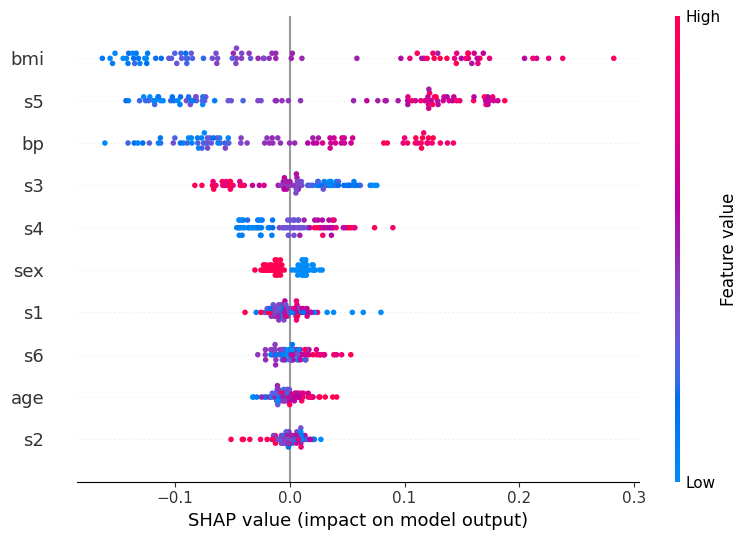

In [11]:
# Summary plot for class "high" (1)
shap.summary_plot(shap_values_rf[:, :, 1], X_test, feature_names=feature_labels)

#### Global feature importance: Bar plot

The **bar plot** provides a simpler view of feature importance, showing the mean absolute SHAP value for each feature.  
This is the SHAP-based equivalent to the `feature_importances_` attribute we used with RandomForest before, but computed in a more principled way.

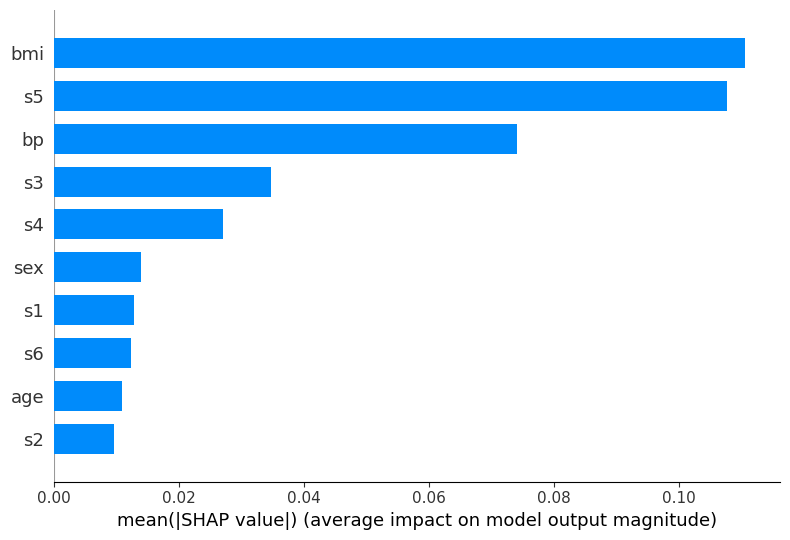

In [12]:
shap.summary_plot(shap_values_rf[:, :, 1], X_test, feature_names=feature_labels, plot_type='bar')

#### Local explanation for individual predictions

Global feature importance tells us which features matter *on average* across all samples.  
But SHAP's most powerful capability is explaining **individual predictions**: for a specific patient, which features drove that particular outcome?

We examine two contrasting cases using the **waterfall plot**:
1. A **correctly classified** sample to see which features provided decisive evidence for the right prediction.
2. A **misclassified** sample to understand which features misled the model across the decision boundary.

First, let's identify one correctly and one incorrectly classified test sample:

In [13]:
# Find the first correctly classified sample
correct_indices = np.where(y_pred_rf == y_test)[0]
true_idx = correct_indices[0]

print(f"Total correct classifications (RF): {len(correct_indices)}")
print("First correctly classified sample:")
print(f"Predicted class: {y_pred_rf[true_idx]} | True class: {y_test[true_idx]}")

# Find the first misclassified sample
wrong_indices = np.where(y_pred_rf != y_test)[0]
false_idx = wrong_indices[0]

print(f"\nTotal misclassifications (RF): {len(wrong_indices)}")
print("First misclassified sample:")
print(f"Predicted class: {y_pred_rf[false_idx]} | True class: {y_test[false_idx]}")

Total correct classifications (RF): 65
First correctly classified sample:
Predicted class: 1 | True class: 1

Total misclassifications (RF): 24
First misclassified sample:
Predicted class: 0 | True class: 1


**How to read the waterfall plot:**
- **E[f(x)]** at the bottom is the *base value*: the model's average predicted probability for class "high" across all training data
- Each horizontal bar represents one feature
- A **red bar** (positive SHAP value) pushes the predicted probability *higher*, toward class "high"
- A **blue bar** (negative SHAP value) pushes it *lower*, toward class "low"
- Bars are ordered by absolute magnitude: the most influential features appear at the top
- **f(x)** at the top is the final predicted probability for class "high" for this specific patient.
- If f(x) > 0.5, the model classifies the patient as "high"; if f(x) < 0.5, as "low"

##### Correctly classified sample (predicted: high, true: high)

The waterfall plot for this sample shows a clear accumulation of **positive (red) contributions** that push the predicted probability well above the 0.5 decision threshold, leading to a confident and correct "high" prediction.

The features at the top of the plot carry the most weight for this individual decision. Notice how several features reinforce each other: their combined effect shifts f(x) far to the right of E[f(x)]. In a clinical context this means the model identified multiple indicators of high disease progression for this patient simultaneously — giving it strong, consistent grounds for its prediction.

The features with small bars (close to zero) contributed little to this specific prediction, even if they appear important in the global summary plot. This highlights a key advantage of SHAP local explanations: the importance of a feature can vary substantially from patient to patient.

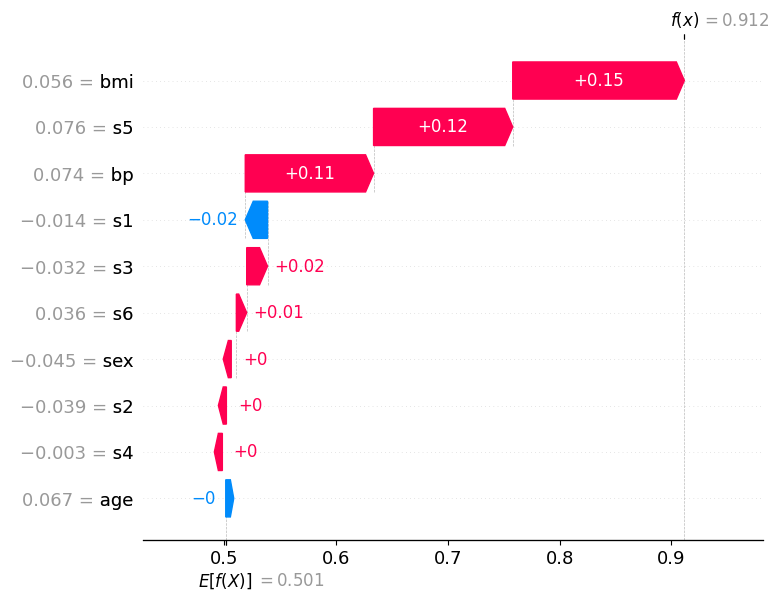

In [14]:
shap.plots.waterfall(shap_exp_rf[true_idx, :, 1])

##### Misclassified sample (predicted: low, true: high)

This patient was misclassified: the model predicted **low** but the true class is **high**. Compare this waterfall carefully to the correct prediction above.

Here, **blue (negative) bars dominate**: multiple features pushed the predicted probability for class "high" *downward* below the 0.5 threshold, causing the model to predict the wrong class. The features that would normally indicate "high" disease progression apparently presented with values the model associates with "low" risk for this particular patient.

Notice the tension in the plot: some red bars may still be present, indicating features that correctly pointed toward "high", but they were **outweighed** by the blue contributions. The net effect dragged f(x) below 0.5, the model crossed the wrong side of the decision boundary.

This is precisely where SHAP becomes most valuable in a clinical setting: instead of knowing only *that* the model was wrong, a physician can see *which measurements* misled it. This enables targeted follow-up questions, e.g., whether those feature values reflect a genuine patient anomaly, a measurement artifact, or a gap in the training data for patients with this particular profile.

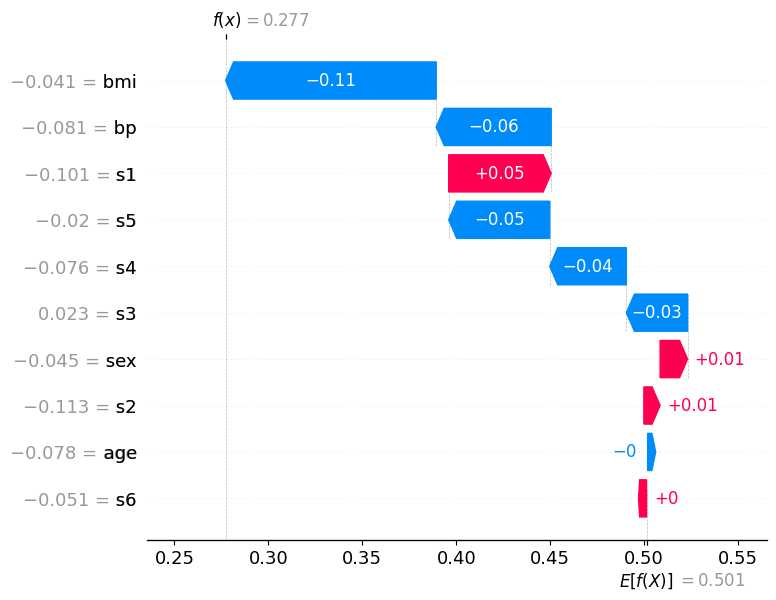

In [15]:
shap.plots.waterfall(shap_exp_rf[false_idx, :, 1])

## Part 2: MLP Classifier (Neural Network)

Now we train a [`MLPClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) (Multi-Layer Perceptron) on the same data. Neural networks are often considered "black box" models because their internal weights are difficult to interpret directly. This is where SHAP becomes especially valuable.

**Important**: Neural networks typically require **feature scaling** (standardization or normalization) to work well. We use [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) for this.

In [16]:
from sklearn.preprocessing import StandardScaler

# Scale the features — fit only on training data, then transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling - mean of first feature (train):", f"{X_train[:, 0].mean():.4f}")
print("After scaling  - mean of first feature (train):", f"{X_train_scaled[:, 0].mean():.4f}")
print("After scaling  - std of first feature (train):", f"{X_train_scaled[:, 0].std():.4f}")

Before scaling - mean of first feature (train): -0.0013
After scaling  - mean of first feature (train): 0.0000
After scaling  - std of first feature (train): 1.0000


### Training the MLP

In [17]:
import warnings

from sklearn.neural_network import MLPClassifier

# Define the parameter grid for the MLP
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
}

# Set up GridSearchCV
grid_search_mlp = GridSearchCV(
    estimator=MLPClassifier(max_iter=1000, random_state=42, verbose=False),
    param_grid=param_grid_mlp,
    scoring='accuracy',
    cv=5
)

# Train with grid search using scaled data, suppress any warnings in the output
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    grid_search_mlp.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search_mlp.best_params_)
print(f"Best cross-validation accuracy: {grid_search_mlp.best_score_:.3f}")

best_mlp = grid_search_mlp.best_estimator_

Best parameters: {'activation': 'relu', 'hidden_layer_sizes': (100,)}
Best cross-validation accuracy: 0.697


### Evaluation

MLP - Classification Report:
              precision    recall  f1-score   support

         low       0.73      0.71      0.72        45
        high       0.71      0.73      0.72        44

    accuracy                           0.72        89
   macro avg       0.72      0.72      0.72        89
weighted avg       0.72      0.72      0.72        89



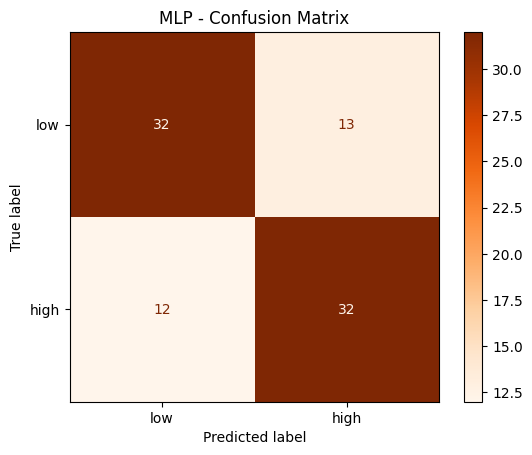

In [18]:
# Predict on test data (scaled!)
y_pred_mlp = best_mlp.predict(X_test_scaled)

# Print evaluation metrics
print("MLP - Classification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=['low', 'high']))

# Confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=['low', 'high'])
disp.plot(cmap='Oranges')
plt.title('MLP - Confusion Matrix')
plt.show()

### Explainability with SHAP

For neural networks, we cannot use the `TreeExplainer`. Instead, we use the more general [`KernelExplainer`](https://shap.readthedocs.io/en/latest/generated/shap.KernelExplainer.html), which works for **any** model. It approximates SHAP values using a weighted linear regression around each prediction, which makes it considerably slower than `TreeExplainer`.

For large datasets, it is recommended to apply `KernelExplainer` to a **background dataset** to estimate the expected model output, the baseline from which all feature contributions are measured. Using the entire training set would be very slow, so you may use [`shap.sample`](https://shap.readthedocs.io/en/latest/generated/shap.sample.html) to draw a random subsample of training samples as the background. This is a common practical trade-off between accuracy and computation time.

In [19]:
# Create a KernelExplainer for our MLP model (works for any model, not just trees)
explainer_mlp = shap.KernelExplainer(best_mlp.predict_proba, X_test_scaled, feature_names=feature_labels)

# Compute SHAP values for the test data (as numpy arrays, shape: n_samples x n_features x n_classes)
# Note: this may take a moment — KernelExplainer is model-agnostic and slower than TreeExplainer
shap_values_mlp = explainer_mlp.shap_values(X_test_scaled)

  0%|          | 0/89 [00:00<?, ?it/s]

#### Summary plot (MLP)

In [20]:
# shap_values_mlp is a 3D array with shape (n_samples, n_features, n_classes)
print("Shape of SHAP values array:", shap_values_mlp.shape)
print(f"This means: for each of the {X_test_scaled.shape[0]} test samples, we have {X_test_scaled.shape[1]} SHAP values per class")
print("\nTo get SHAP values for class 'high' (1): shap_values_mlp[:, :, 1] has shape", shap_values_mlp[:, :, 1].shape)

Shape of SHAP values array: (89, 10, 2)
This means: for each of the 89 test samples, we have 10 SHAP values per class

To get SHAP values for class 'high' (1): shap_values_mlp[:, :, 1] has shape (89, 10)


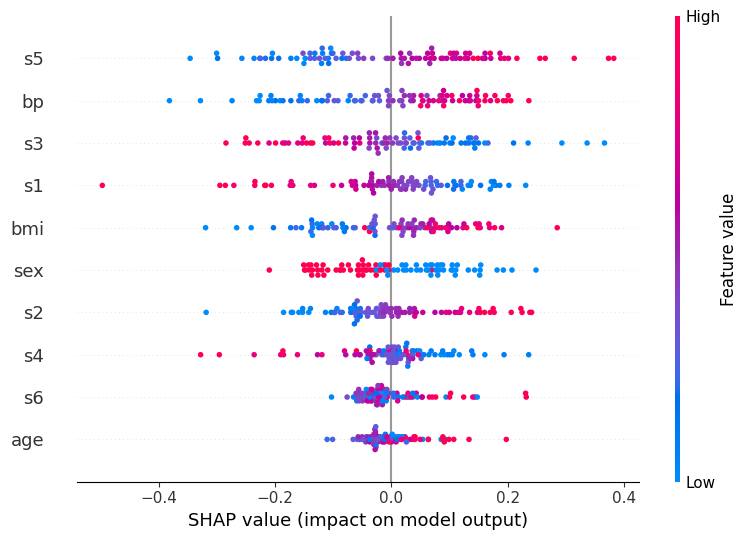

In [21]:
# Summary plot for class "high" (1)
shap.summary_plot(shap_values_mlp[:, :, 1], X_test_scaled, feature_names=feature_labels)

#### Bar plot (MLP)

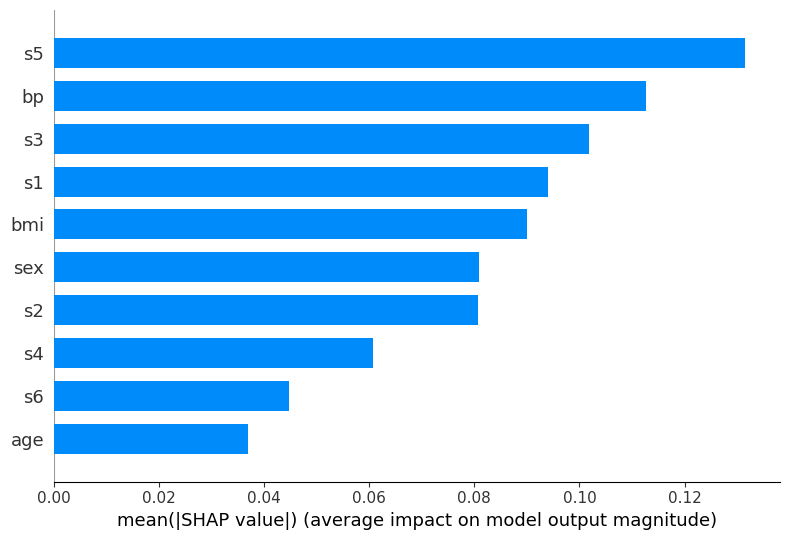

In [22]:
shap.summary_plot(shap_values_mlp[:, :, 1], X_test_scaled, feature_names=feature_labels, plot_type='bar')

## Part 3: Comparison

Let's compare the SHAP-based feature importances from both models side by side.  
This helps to understand whether both models agree on which features are most important, or whether the neural network learned different patterns.

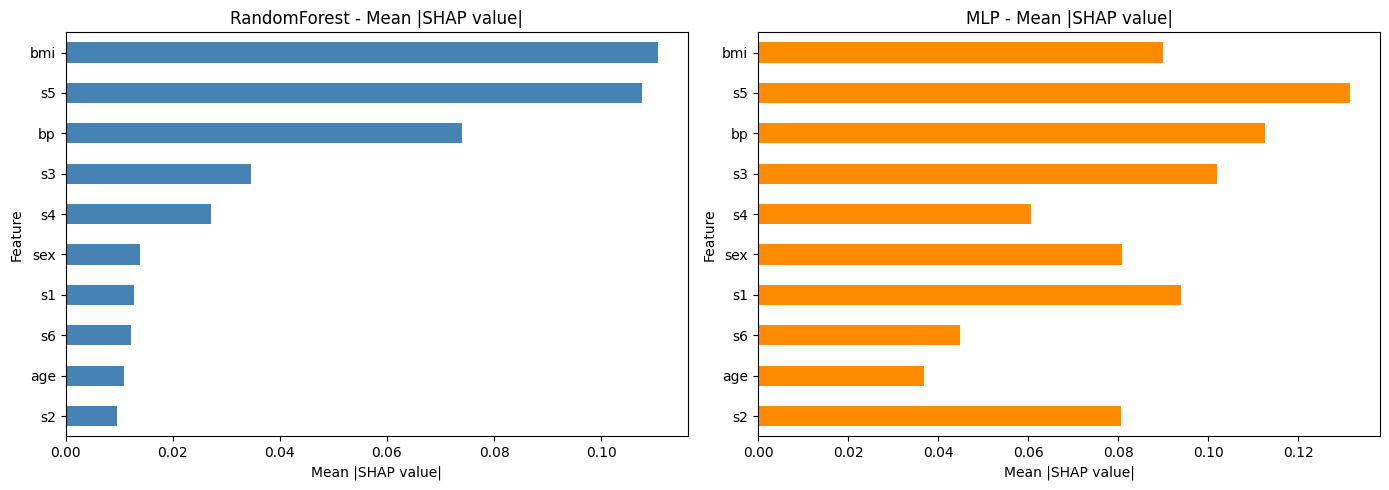

In [23]:
# Compute mean absolute SHAP values for both models (class "high")
rf_importance = np.abs(shap_values_rf[:, :, 1]).mean(axis=0)
mlp_importance = np.abs(shap_values_mlp[:, :, 1]).mean(axis=0)

# Create a comparison DataFrame
comparison = pd.DataFrame({
    'Feature': feature_labels,
    'RandomForest': rf_importance,
    'MLP': mlp_importance
}).set_index('Feature')

# Sort by RandomForest importance
comparison = comparison.sort_values('RandomForest', ascending=True)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison['RandomForest'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('RandomForest - Mean |SHAP value|')
axes[0].set_xlabel('Mean |SHAP value|')

comparison['MLP'].plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('MLP - Mean |SHAP value|')
axes[1].set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.show()

### Discussion

Take a moment to reflect on the following questions:

* Do both models agree on the most important features? Which features differ?
* Looking at the summary plots: does a high feature value always lead to a higher prediction? Or is the relationship more complex for some features?
* What are the advantages of SHAP over the built-in `feature_importances_` from the RandomForest?

## Exercise: Explore SHAP on your own

Now it's your turn! Try the following task to deepen your understanding of SHAP and model explainability.

**If you get stuck, remember that our assistant bia-bob is available and very happy to help you.**

### Local explanation for individual predictions for MLP

For MLP, also examine two contrasting cases using the **waterfall plot**:
1. A **correctly classified** sample
2. A **misclassified** sample

In [24]:
# ToDo: waterfall plots for MLP

### Use a different dataset

Try applying SHAP to a model trained on the [scikit-learn breast cancer dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset) that you already know from the previous session.

Steps:
* Load the breast cancer dataset
* Train a RandomForest or MLP classifier
* Compute and visualize SHAP values
* Which features are most important for distinguishing benign from malignant tumors?

In [25]:
# ToDo: apply SHAP to the breast cancer dataset